In [ ]:
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

In [ ]:
TRAIN_PATH = "dataset_clean/train.csv"
TEST_PATH = "dataset_clean/test.csv"
IMAGE_DIR = "image"
RANDOM_STATE = 42
TARGET = "category_grouped"

os.makedirs(IMAGE_DIR, exist_ok=True)

In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


def clean_authors(value):
    """แปลง "['A', 'B']" ให้เป็น "A B" """
    return re.sub(r"[\[\]']", " ", str(value)).replace('"', " ").strip()


def prepare(df):
    df = df.copy()
    df["description"] = df["description"].fillna("")
    df["authors"] = df["authors"].fillna("").apply(clean_authors)
    df["publisher"] = df["publisher"].fillna("").astype(str)
    df["Title"] = df["Title"].fillna("").astype(str)
    df["text"] = df["Title"] + " " + df["description"]
    df["ratingsCount"] = np.log1p(df["ratingsCount"].fillna(0))
    return df


train_df = prepare(train_df)
test_df = prepare(test_df)

FEATURES = ["text", "authors", "publisher",
            "ratingsCount", "year", "has_rating", "has_description"]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

class_names = y_train.value_counts().index.tolist()  # เรียงตามจำนวนมากไปน้อย

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"จำนวนคลาส: {len(class_names)}")
print(y_train.value_counts(), "\n")

Train: (2613, 7) | Test: (654, 7)
จำนวนคลาส: 16
category_grouped
Fiction                      838
Other                        700
Juvenile Fiction             153
History                      153
Religion                     145
Biography & Autobiography    138
Business & Economics          74
Juvenile Nonfiction           62
Social Science                53
Young Adult Fiction           51
Comics & Graphic Novels       48
Science                       48
Political Science             46
Medical                       39
Literary Criticism            37
Philosophy                    28
Name: count, dtype: int64 



In [ ]:
def build_preprocessor():
    return ColumnTransformer([
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2,
                                 max_features=20000, sublinear_tf=True), "text"),
        ("authors", TfidfVectorizer(min_df=1, max_features=3000), "authors"),
        ("publisher", TfidfVectorizer(min_df=1, max_features=2000), "publisher"),
        ("num", MinMaxScaler(), ["ratingsCount", "year",
                                 "has_rating", "has_description"]),
    ])



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Naive Bayes": (
        MultinomialNB(),
        {"clf__alpha": [0.01, 0.05, 0.1, 0.5, 1.0]},  # Laplace smoothing
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                               max_features="sqrt", class_weight="balanced"),
        {"clf__n_estimators": [100, 200],
         "clf__max_depth": [None, 50],
         "clf__min_samples_split": [2, 5]},
    ),
    "SVM": (
        SVC(random_state=RANDOM_STATE, class_weight="balanced"),
        {"clf__kernel": ["linear", "rbf"],
         "clf__C": [0.1, 1, 10],
         "clf__gamma": ["scale"]},
    ),
}


In [ ]:
def plot_heatmap(cm, labels, title, save_path, fmt="d", cmap="Blues"):
    plt.figure(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.4, linecolor="white",
                annot_kws={"size": 8}, cbar=True)
    plt.title(title, fontsize=15, fontweight="bold", pad=15)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

กำลังเทรน: Naive Bayes
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params      : {'clf__alpha': 0.01}
Best CV F1-macro : 46.68%
Test Accuracy    : 63.91%
Test F1 (macro)  : 47.68%
Test F1 (weighted): 62.53%
เวลาที่ใช้        : 11.7 วินาที

                           precision    recall  f1-score   support

                  Fiction       0.77      0.87      0.82       214
                    Other       0.57      0.70      0.62       171
         Juvenile Fiction       0.74      0.56      0.63        36
                  History       0.45      0.43      0.44        42
                 Religion       0.77      0.68      0.72        25
Biography & Autobiography       0.52      0.30      0.38        46
     Business & Economics       0.78      0.33      0.47        21
      Juvenile Nonfiction       0.78      0.47      0.58        15
           Social Science       0.00      0.00      0.00         5
      Young Adult Fiction       0.36      0.29      0.32        14
 

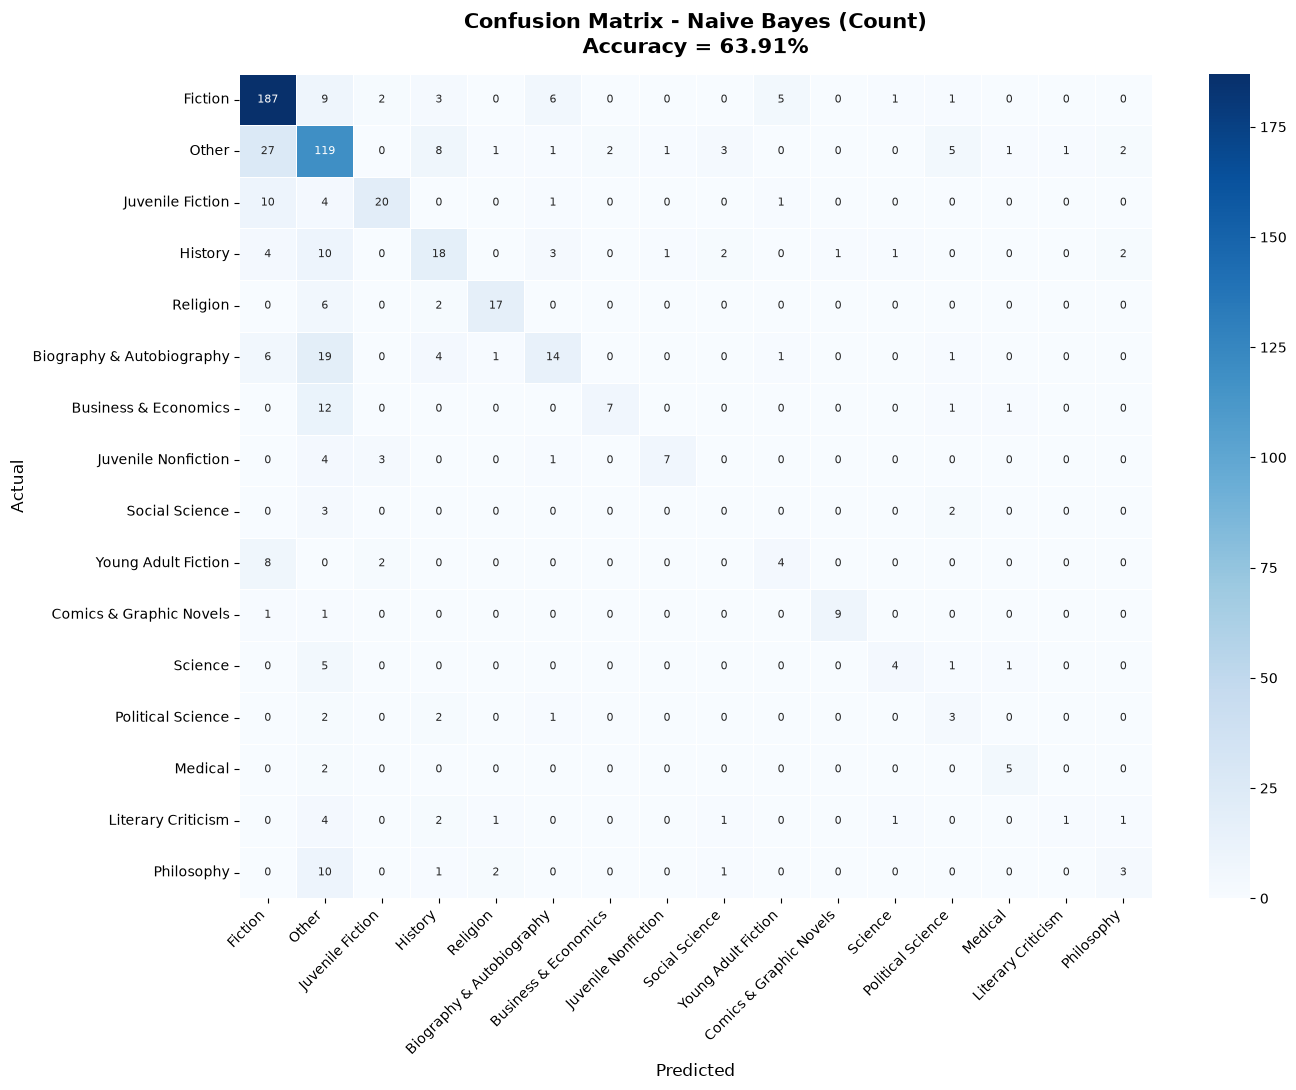

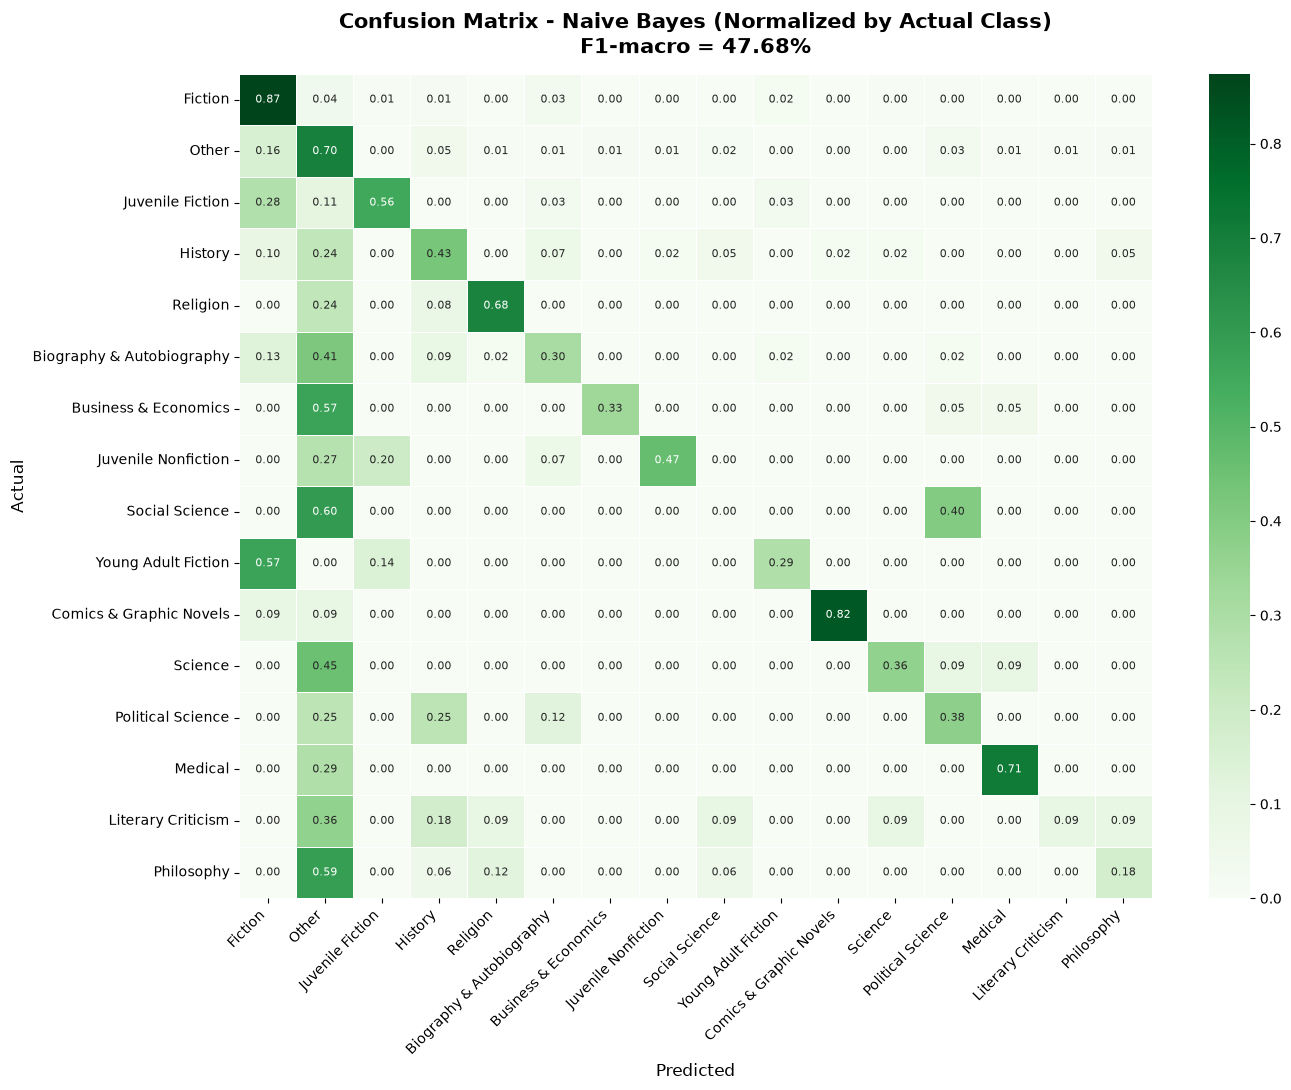

กำลังเทรน: Random Forest
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params      : {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1-macro : 49.77%
Test Accuracy    : 62.23%
Test F1 (macro)  : 52.31%
Test F1 (weighted): 61.84%
เวลาที่ใช้        : 26.6 วินาที

                           precision    recall  f1-score   support

                  Fiction       0.77      0.77      0.77       214
                    Other       0.56      0.63      0.59       171
         Juvenile Fiction       0.49      0.58      0.53        36
                  History       0.41      0.55      0.47        42
                 Religion       0.59      0.88      0.71        25
Biography & Autobiography       0.58      0.39      0.47        46
     Business & Economics       0.71      0.48      0.57        21
      Juvenile Nonfiction       0.71      0.33      0.45        15
           Social Science       0.00      0.00      0.00         5
      Y

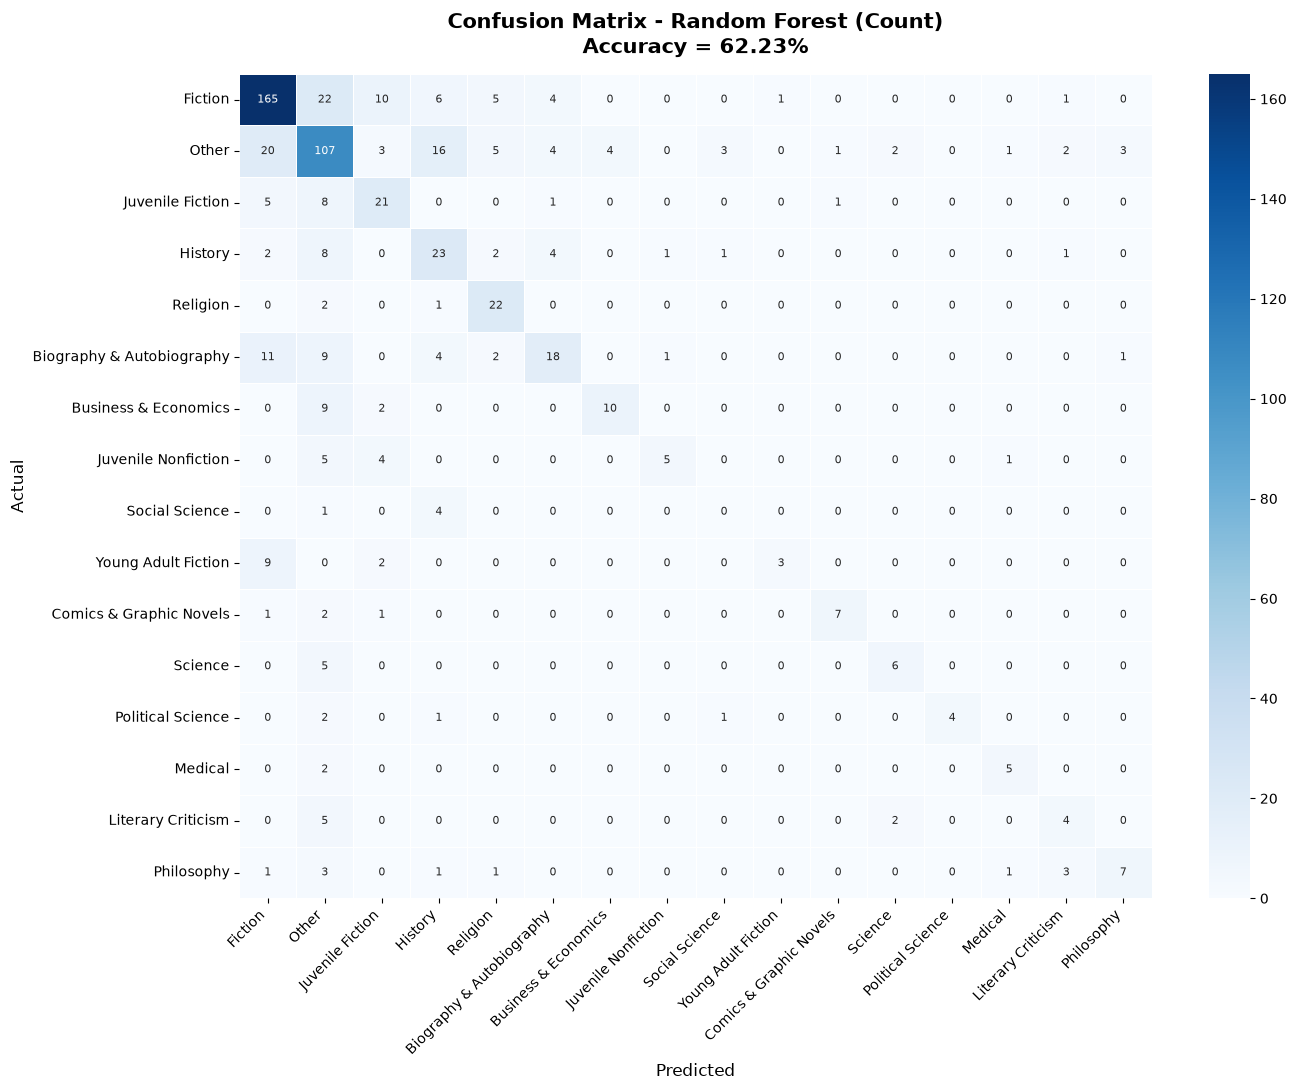

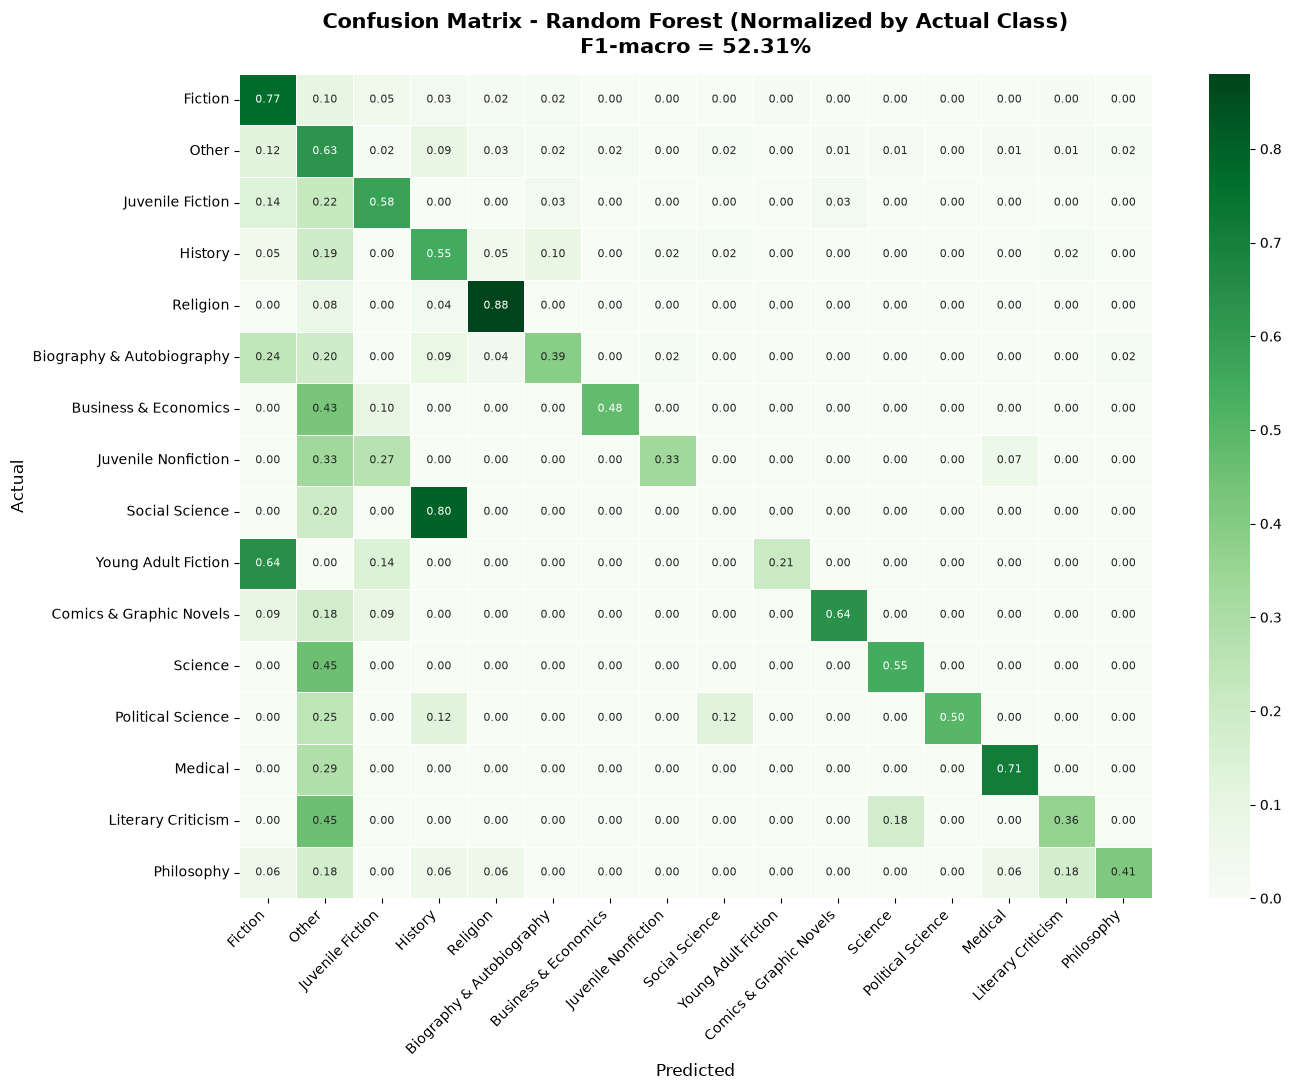

กำลังเทรน: SVM
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params      : {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Best CV F1-macro : 41.41%
Test Accuracy    : 61.31%
Test F1 (macro)  : 44.88%
Test F1 (weighted): 58.94%
เวลาที่ใช้        : 110.0 วินาที

                           precision    recall  f1-score   support

                  Fiction       0.70      0.84      0.76       214
                    Other       0.53      0.71      0.61       171
         Juvenile Fiction       0.64      0.50      0.56        36
                  History       0.37      0.38      0.38        42
                 Religion       0.94      0.64      0.76        25
Biography & Autobiography       0.53      0.35      0.42        46
     Business & Economics       0.58      0.33      0.42        21
      Juvenile Nonfiction       1.00      0.33      0.50        15
           Social Science       0.00      0.00      0.00         5
      Young Adult Fiction       0.

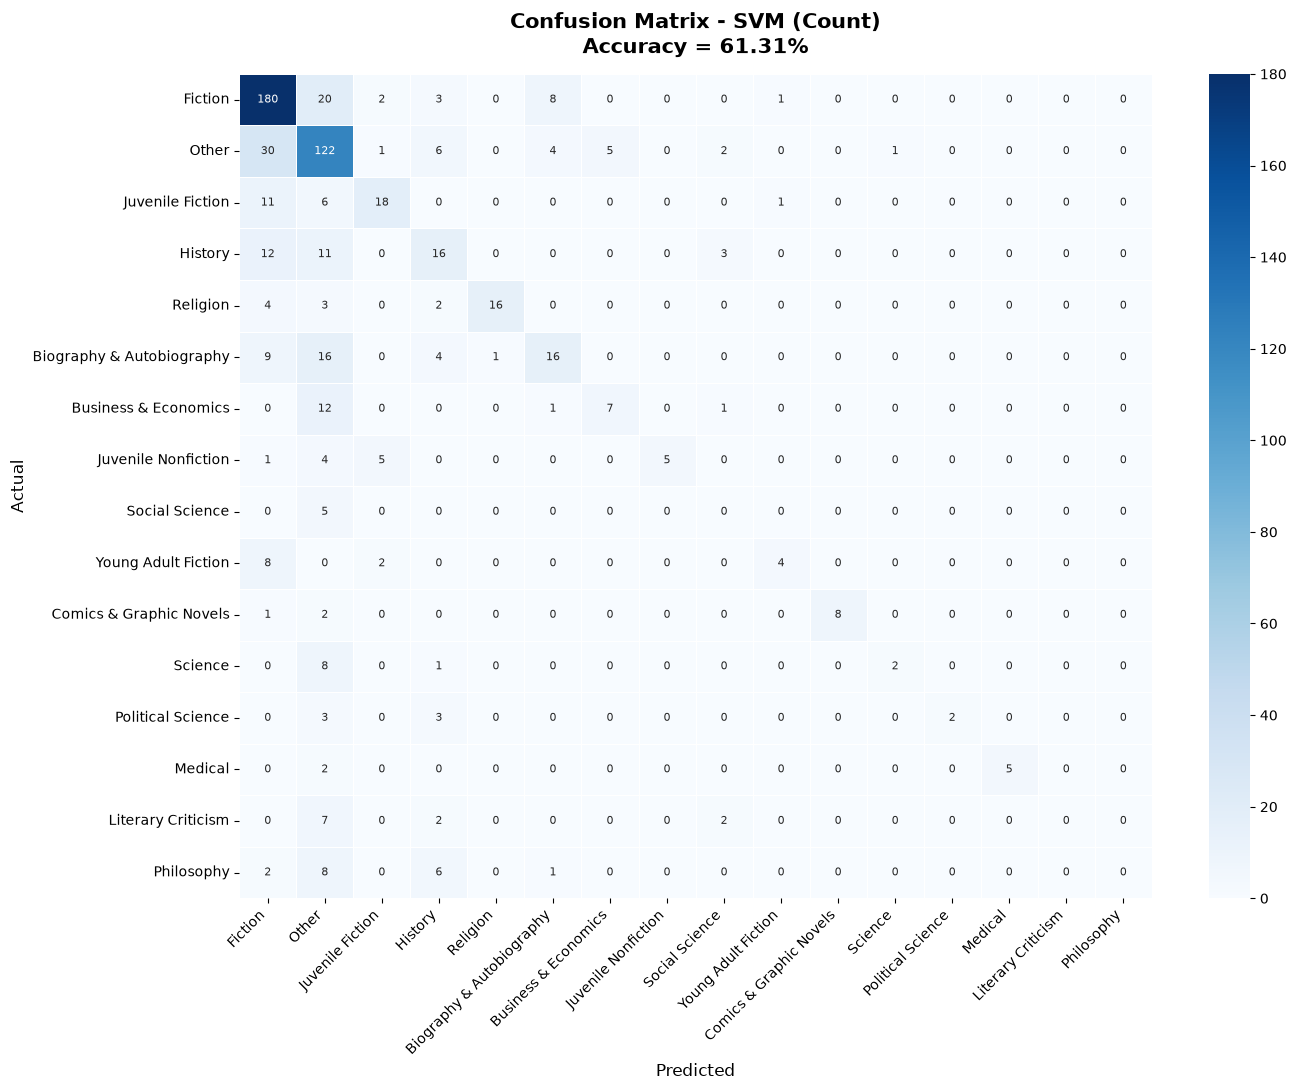

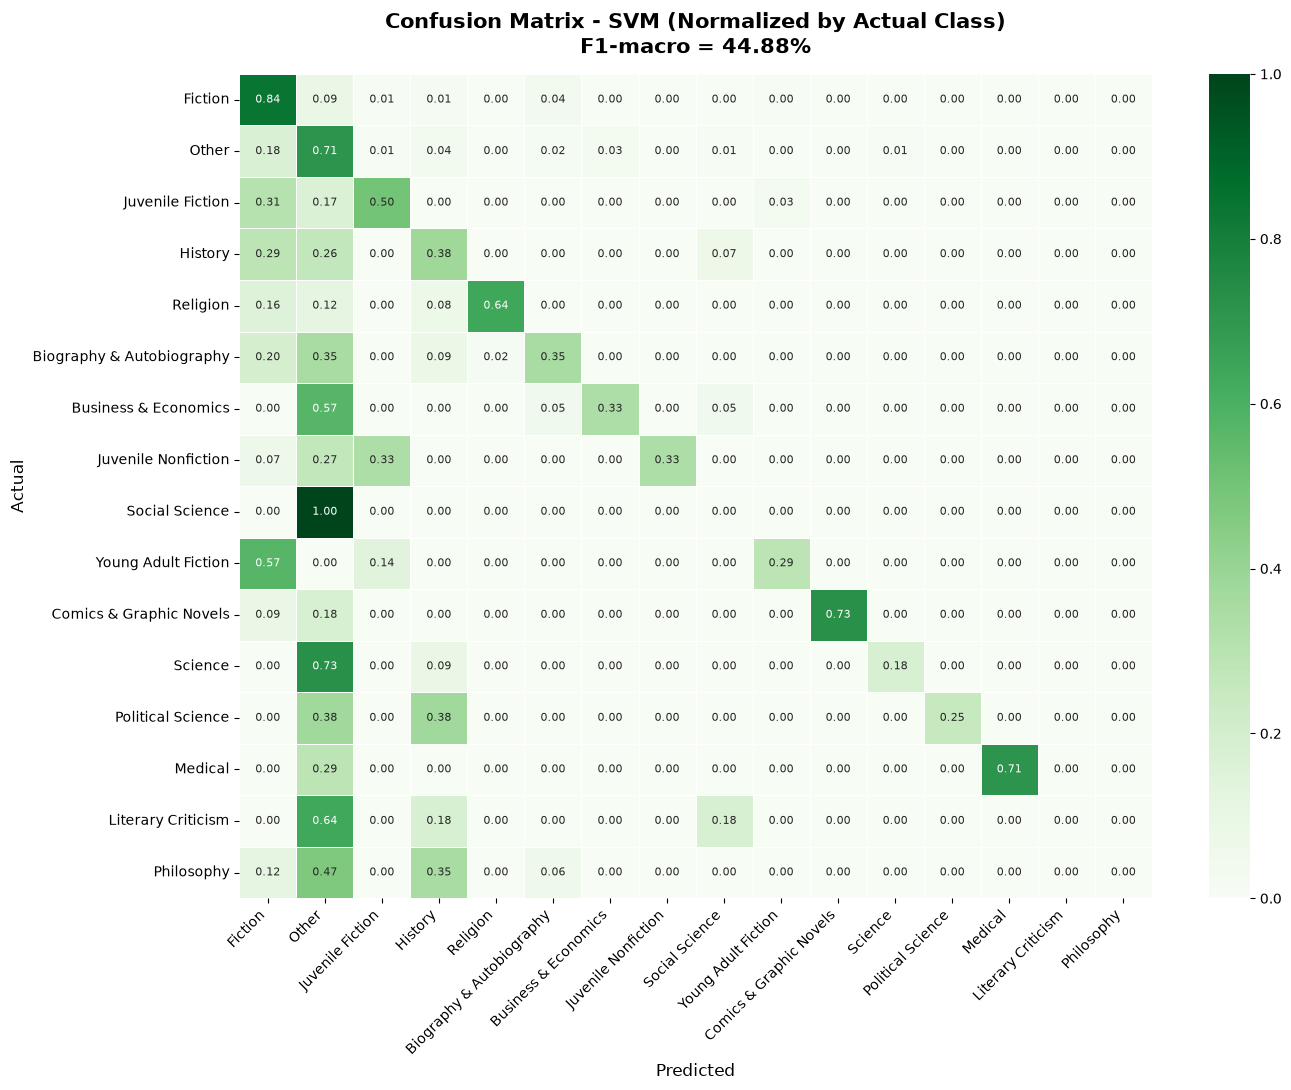

In [ ]:
results = []

for name, (estimator, param_grid) in models.items():
    print("=" * 70)
    print(f"กำลังเทรน: {name}")
    print("=" * 70)

    pipe = Pipeline([("prep", build_preprocessor()), ("clf", estimator)])
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1_macro",
                        n_jobs=-1, verbose=1)

    start = time.time()
    grid.fit(X_train, y_train)
    elapsed = time.time() - start

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"Best Params      : {grid.best_params_}")
    print(f"Best CV F1-macro : {grid.best_score_:.2%}")
    print(f"Test Accuracy    : {acc:.2%}")
    print(f"Test F1 (macro)  : {f1_macro:.2%}")
    print(f"Test F1 (weighted): {f1_weighted:.2%}")
    print(f"เวลาที่ใช้        : {elapsed:.1f} วินาที\n")
    print(classification_report(y_test, y_pred, labels=class_names,
                                zero_division=0))

    safe_name = name.lower().replace(" ", "_")

    # Heatmap 1: จำนวนจริง
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    plot_heatmap(cm, class_names,
                 f"Confusion Matrix - {name} (Count)\nAccuracy = {acc:.2%}",
                 os.path.join(IMAGE_DIR, f"heatmap_{safe_name}_count.png"),
                 fmt="d", cmap="Blues")

    # Heatmap 2: เปอร์เซ็นต์ต่อแถว (Recall ของแต่ละคลาส)
    cm_norm = confusion_matrix(y_test, y_pred, labels=class_names,
                               normalize="true")
    plot_heatmap(cm_norm, class_names,
                 f"Confusion Matrix - {name} (Normalized by Actual Class)\n"
                 f"F1-macro = {f1_macro:.2%}",
                 os.path.join(IMAGE_DIR, f"heatmap_{safe_name}_normalized.png"),
                 fmt=".2f", cmap="Greens")

    results.append({"Model": name, "Accuracy": acc,
                    "F1 (macro)": f1_macro, "F1 (weighted)": f1_weighted})

สรุปผลเปรียบเทียบ
              Accuracy F1 (macro) F1 (weighted)
Model                                          
Naive Bayes     63.91%     47.68%        62.53%
Random Forest   62.23%     52.31%        61.84%
SVM             61.31%     44.88%        58.94%


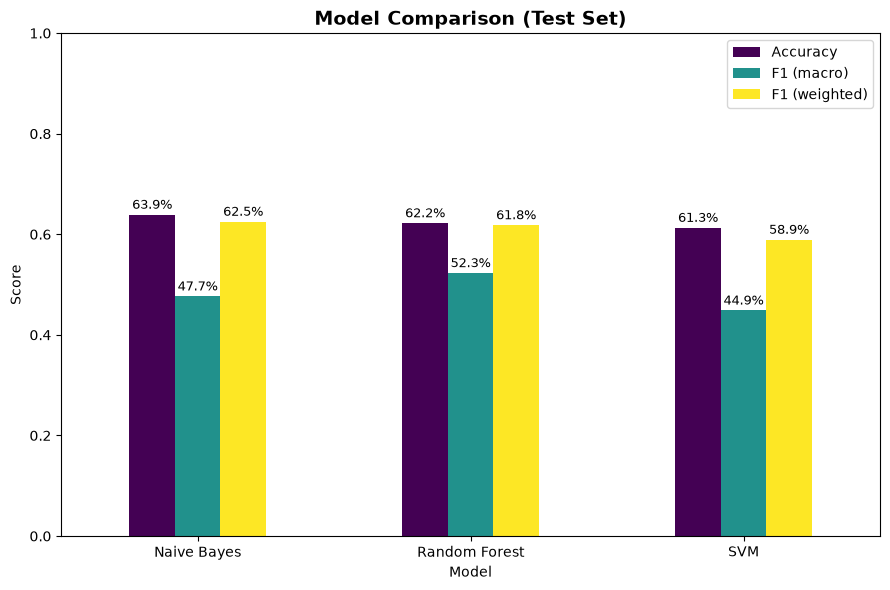


บันทึกภาพทั้งหมดในโฟลเดอร์ 'image' เรียบร้อยแล้ว


In [ ]:
summary = pd.DataFrame(results).set_index("Model")
print("=" * 70)
print("สรุปผลเปรียบเทียบ")
print("=" * 70)
print((summary * 100).round(2).astype(str) + "%")

ax = summary.plot(kind="bar", figsize=(9, 6), rot=0, colormap="viridis")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in container.datavalues],
                 fontsize=9, padding=2)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "model_comparison.png"),
            dpi=200, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nบันทึกภาพทั้งหมดในโฟลเดอร์ '{IMAGE_DIR}' เรียบร้อยแล้ว")

In [ ]:
future_year = train_df["year"].max() + 1
future_df = test_df[test_df["year"] == future_year].copy()
X_future = future_df[FEATURES]

future_predictions = {}

for model_name, (estimator, param_grid) in models.items():
    pipeline = Pipeline([
        ("prep", build_preprocessor()),
        ("clf", estimator)
    ])

    model_grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    model_grid.fit(X_train, y_train)

    future_predictions[model_name] = model_grid.best_estimator_.predict(X_future)

future_summary = pd.DataFrame({
    model_name: pd.Series(preds).value_counts(normalize=True).mul(100)
    for model_name, preds in future_predictions.items()
}).fillna(0).round(2)

print(f"สัดส่วนผลการทำนายสำหรับปี {future_year} (%)")
display(future_summary.sort_index().style.format("{:.2f}%"))

print("\nประเภทที่มีสัดส่วนการทำนายสูงสุดของแต่ละโมเดล:")
for model_name in future_summary.columns:
    max_percentage = future_summary[model_name].max()
    top_categories = future_summary.index[
        future_summary[model_name] == max_percentage
    ].tolist()
    print(f"{model_name}: {', '.join(top_categories)} ({max_percentage:.2f}%)")

ผลการทำนายสำหรับปี 2023


,Naive Bayes,Random Forest,SVM
Biography & Autobiography,1,0,0
Fiction,1,2,2
History,0,0,1
Juvenile Fiction,0,1,0
Other,4,3,4
Political Science,1,0,0
Religion,1,1,1
Science,0,1,0



ประเภทที่มีจำนวนทำนายสูงสุดของแต่ละโมเดล:
Naive Bayes: Other (4 เล่ม)
Random Forest: Other (3 เล่ม)
SVM: Other (4 เล่ม)
